In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from torch.distributions import Normal, Uniform

import sys
sys.path.append('../drnpe')

import lightning

from hydra import compose, initialize
from hydra.utils import instantiate

import matplotlib.pyplot as plt

import math

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


We load the configs and instantiate the data module:

In [2]:
with initialize(version_base=None, config_path="../drnpe/conf"):
    cfg_npe_gaussian = compose(config_name="config_npe")
    cfg_drnpe_gaussian = compose(config_name="config_drnpe")
    cfg_npe_flow = compose(config_name="config_npe_flow")
    cfg_drnpe_flow = compose(config_name="config_drnpe_flow")

lightning.seed_everything(cfg_npe_gaussian.seed)

datamodule = instantiate(cfg_npe_gaussian.datamodule)

Seed set to 42


## Gaussian Variational Distribution Encoders

We load encoders trained with a Gaussian variational distribution:

In [3]:
# NPE with Gaussian variational distribution
encoder_npe_gaussian = instantiate(cfg_npe_gaussian.encoder)
state_dict = torch.load("../trained_ckpts/network_npe.ckpt", map_location=device)['state_dict']
encoder_npe_gaussian.load_state_dict(state_dict)
encoder_npe_gaussian = encoder_npe_gaussian.to(device).eval()

# DRNPE with Gaussian variational distribution
encoder_drnpe_gaussian = instantiate(cfg_drnpe_gaussian.encoder)
state_dict = torch.load("../trained_ckpts/network_drnpe_dual.ckpt", map_location=device)['state_dict']
encoder_drnpe_gaussian.load_state_dict(state_dict)
encoder_drnpe_gaussian = encoder_drnpe_gaussian.to(device).eval()

print("Loaded Gaussian encoders")

Loaded Gaussian encoders


## Neural Spline Flow Encoders

We load encoders trained with neural spline flow variational distributions:

In [4]:
# NPE with neural spline flow
encoder_npe_flow = instantiate(cfg_npe_flow.encoder)
state_dict = torch.load("../trained_ckpts/network_npe_flow.ckpt", map_location=device)['state_dict']
encoder_npe_flow.load_state_dict(state_dict)
encoder_npe_flow = encoder_npe_flow.to(device).eval()

# DRNPE with neural spline flow
encoder_drnpe_flow = instantiate(cfg_drnpe_flow.encoder)
state_dict = torch.load("../trained_ckpts/network_drnpe_dual_flow.ckpt", map_location=device)['state_dict']
encoder_drnpe_flow.load_state_dict(state_dict)
encoder_drnpe_flow = encoder_drnpe_flow.to(device).eval()

print("Loaded flow encoders")

Loaded flow encoders


## Coverage Functions

We define functions to plot nominal versus empirical coverage probabilities. The `misspec_param` controls the likelihood standard deviation multiplier - a value of 1.0 means correctly specified, other values indicate misspecification.

In [5]:
def plot_coverage_probabilities(num_test_samples, encoder, misspec_param, title=""):
    """Coverage plot for Gaussian encoders using analytical quantiles."""
    num_subplots = len(misspec_param)
    fig, ax = plt.subplots(1, num_subplots, figsize=(4 * num_subplots, 4))
    if num_subplots == 1:
        ax = [ax]
    
    for j in range(num_subplots):
        z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples]).to(device)
        x_raw = Normal(z, misspec_param[j] * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1, 0)
        
        # Compute sufficient statistics
        sample_mean = x_raw.mean(dim=1, keepdim=True)
        sample_var = x_raw.var(dim=1, unbiased=False, keepdim=True)
        x = torch.cat([sample_mean, sample_var], dim=1)

        with torch.inference_mode():
            mu, logsigma = encoder.net(x)
            sigma = torch.exp(logsigma)

        confidence_levels = torch.linspace(0.05, 0.95, steps=19)
        quantiles = Normal(0, 1).icdf(1 - (1 - confidence_levels) / 2).to(device)

        lower = mu.unsqueeze(-1) - quantiles * sigma.unsqueeze(-1)
        upper = mu.unsqueeze(-1) + quantiles * sigma.unsqueeze(-1)

        coverage_probs = ((z.unsqueeze(-1) >= lower) * (z.unsqueeze(-1) <= upper)).float().mean(0)
        
        ax[j].scatter(confidence_levels.cpu(), coverage_probs.cpu())
        ax[j].axline((0, 0), slope=1, color='black')
        ax[j].set_xlim(0, 1)
        ax[j].set_ylim(0, 1)
        ax[j].set_title(f'misspec = {misspec_param[j]}')
        ax[j].set_xlabel('Nominal coverage')
        ax[j].set_ylabel('Empirical coverage')
    
    if title:
        fig.suptitle(title, y=1.02)
    fig.tight_layout()

In [6]:
def plot_coverage_probabilities_flow(num_test_samples, encoder, misspec_param, num_posterior_samples=1000, title=""):
    """Coverage plot for flow-based encoders using Monte Carlo sampling."""
    num_subplots = len(misspec_param)
    fig, ax = plt.subplots(1, num_subplots, figsize=(4 * num_subplots, 4))
    if num_subplots == 1:
        ax = [ax]
    
    for j in range(num_subplots):
        z = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples]).to(device)
        x_raw = Normal(z, misspec_param[j] * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1, 0)
        
        # Compute sufficient statistics
        sample_mean = x_raw.mean(dim=1, keepdim=True)
        sample_var = x_raw.var(dim=1, unbiased=False, keepdim=True)
        x = torch.cat([sample_mean, sample_var], dim=1)
        
        # Sample from the flow posterior on GPU
        with torch.inference_mode():
            posterior_samples = encoder.flow.sample(num_posterior_samples, x)  # [batch, num_samples, z_dim]
            posterior_samples = posterior_samples.squeeze(-1)  # [batch, num_samples]
        
        confidence_levels = torch.linspace(0.05, 0.95, steps=19)
        
        # Compute empirical quantiles from samples
        lower_quantiles = (1 - confidence_levels) / 2
        upper_quantiles = 1 - lower_quantiles
        
        lower = torch.quantile(posterior_samples, lower_quantiles.to(device), dim=1).T  # [batch, num_levels]
        upper = torch.quantile(posterior_samples, upper_quantiles.to(device), dim=1).T
        
        coverage_probs = ((z.unsqueeze(-1) >= lower) * (z.unsqueeze(-1) <= upper)).float().mean(0)
        
        ax[j].scatter(confidence_levels.cpu(), coverage_probs.cpu())
        ax[j].axline((0, 0), slope=1, color='black')
        ax[j].set_xlim(0, 1)
        ax[j].set_ylim(0, 1)
        ax[j].set_title(f'misspec = {misspec_param[j]}')
        ax[j].set_xlabel('Nominal coverage')
        ax[j].set_ylabel('Empirical coverage')
    
    if title:
        fig.suptitle(title, y=1.02)
    fig.tight_layout()

## Results: Gaussian Variational Distribution

### NPE (Gaussian)

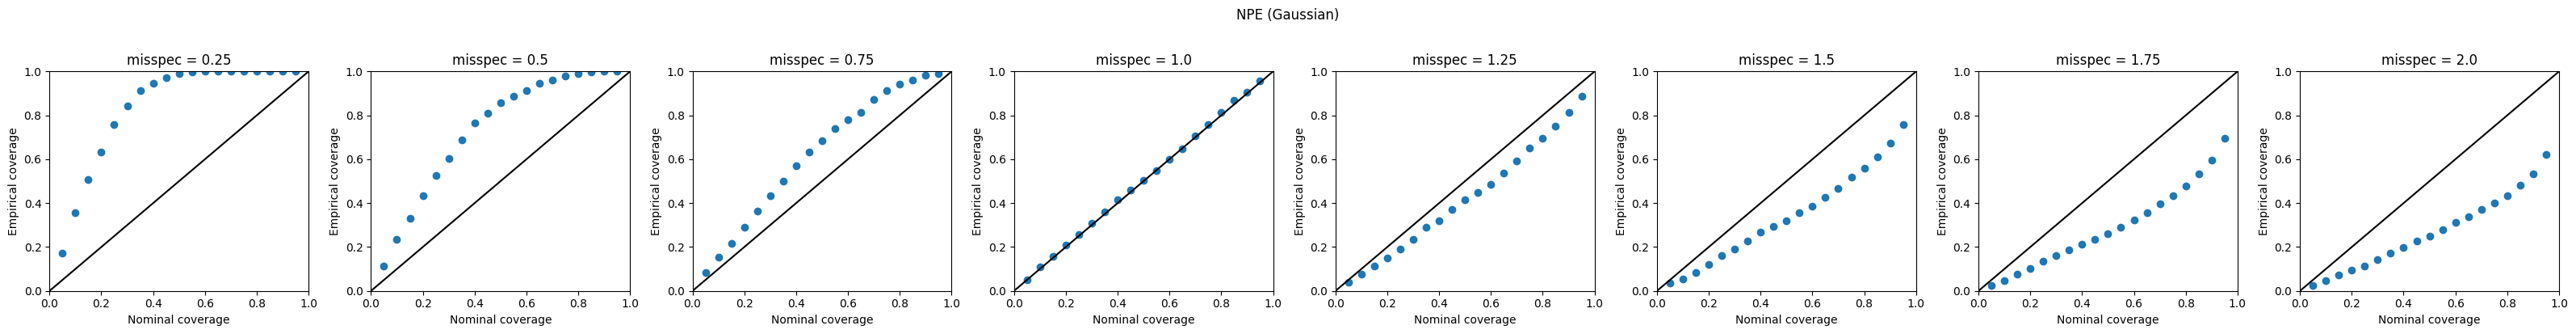

In [7]:
plot_coverage_probabilities(1000, encoder_npe_gaussian, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], title="NPE (Gaussian)")

### DRNPE (Gaussian)

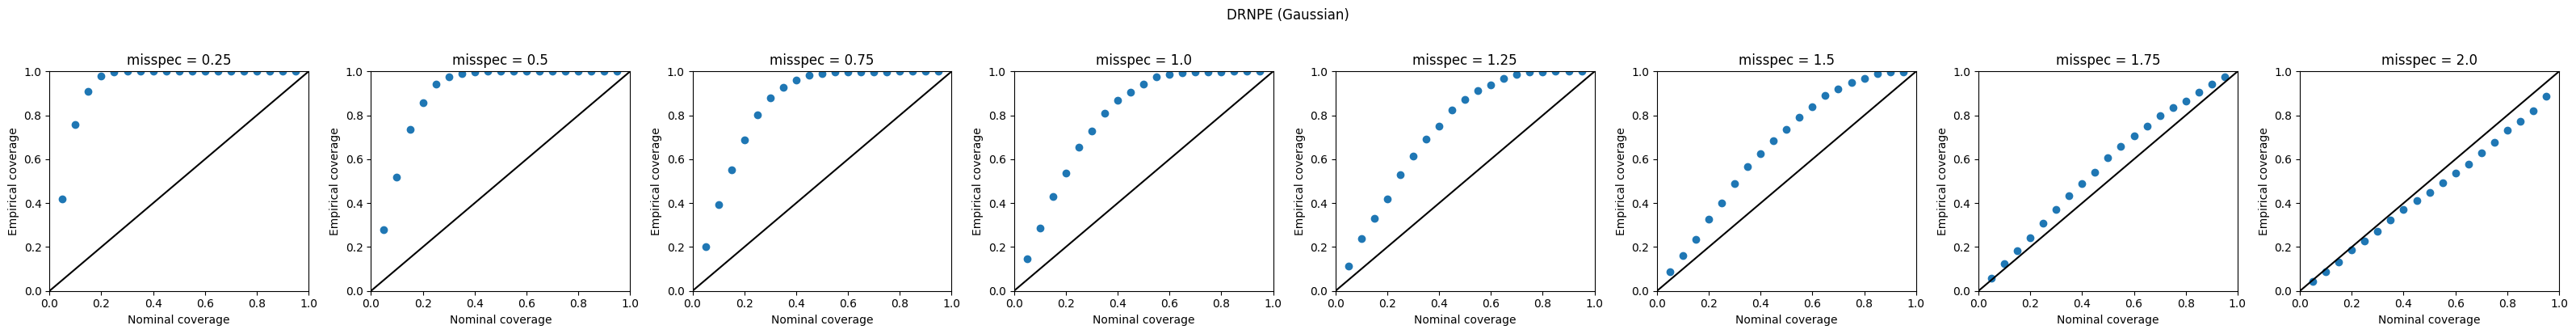

In [8]:
plot_coverage_probabilities(1000, encoder_drnpe_gaussian, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], title="DRNPE (Gaussian)")

## Results: Neural Spline Flow

### NPE (Flow)

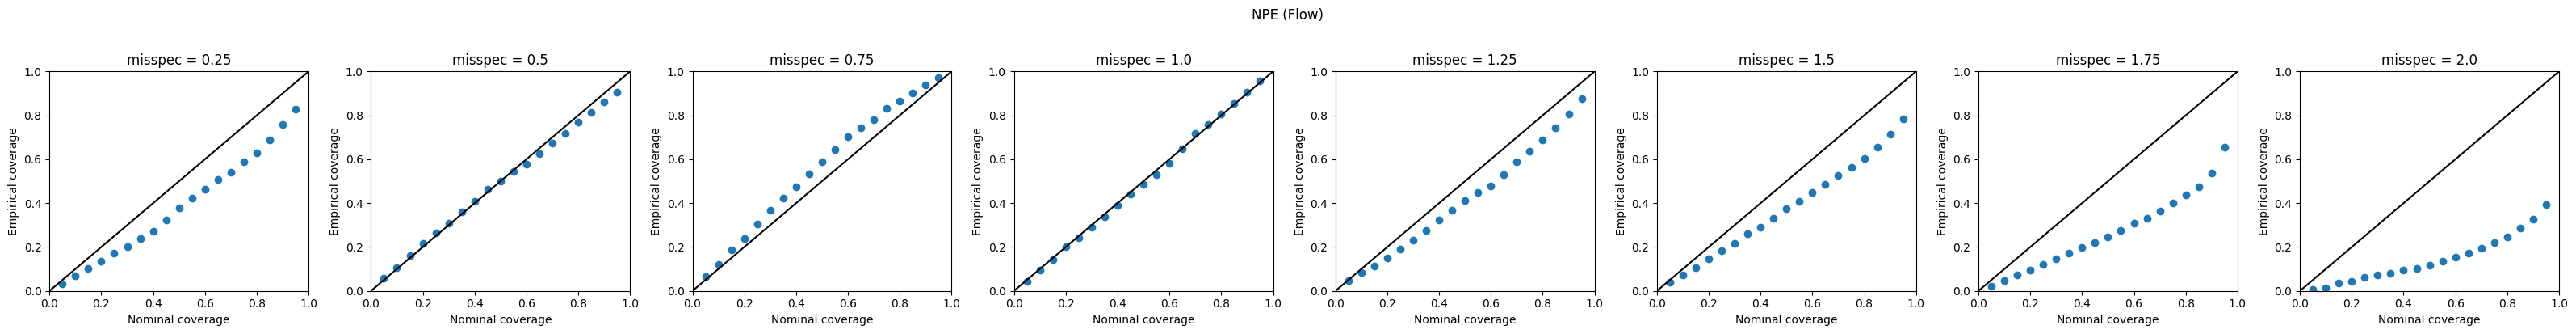

In [9]:
plot_coverage_probabilities_flow(1000, encoder_npe_flow, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], title="NPE (Flow)")

### DRNPE (Flow)

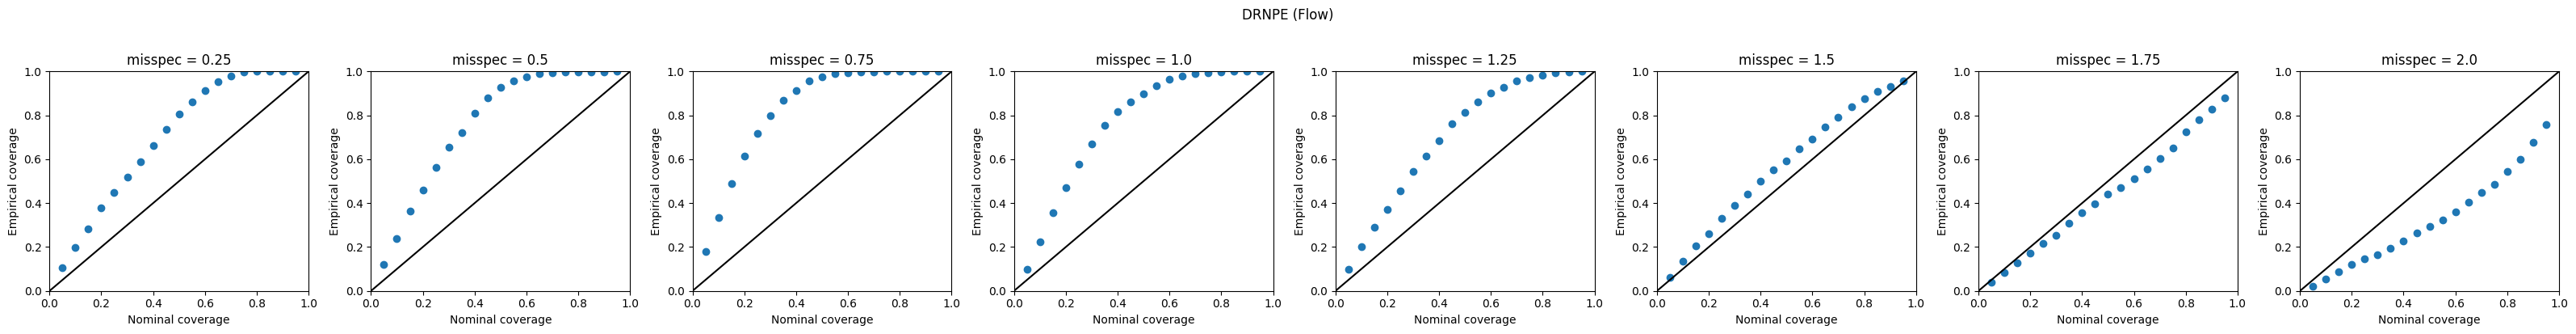

In [10]:
plot_coverage_probabilities_flow(1000, encoder_drnpe_flow, [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], title="DRNPE (Flow)")

## Comparison of Log Variational Densities

We compare the log variational density $\log q(z|x)$ across all four encoders evaluated at the same test points under misspecification (likelihood std multiplier = $\sqrt{2}$):

<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_551191/4086392971.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('$\log q(z|x)$')


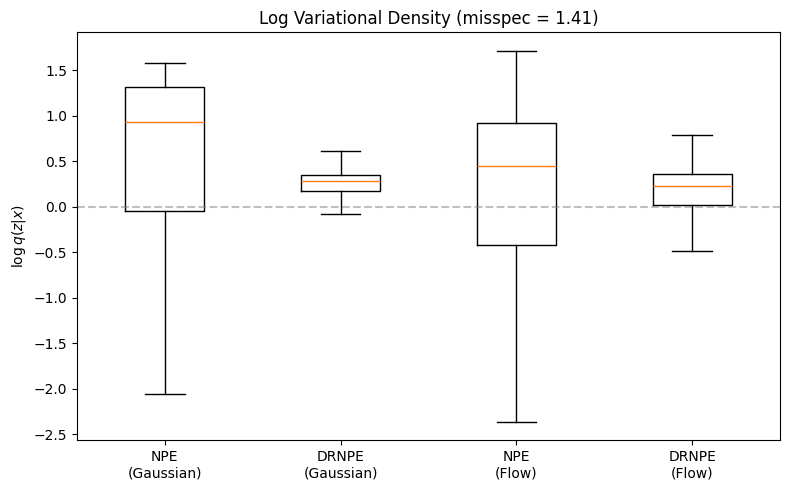

In [11]:
# Generate test data under misspecification
num_test_samples = 1000
misspec_param = math.sqrt(2.0)

z_test = Normal(0.0, datamodule.prior_stdev).sample([num_test_samples]).to(device)
x_raw = Normal(z_test, misspec_param * datamodule.likelihood_stdev).sample([datamodule.num_observations]).permute(1, 0)

# Compute sufficient statistics
sample_mean = x_raw.mean(dim=1, keepdim=True)
sample_var = x_raw.var(dim=1, unbiased=False, keepdim=True)
x_test = torch.cat([sample_mean, sample_var], dim=1)

# Compute log q for each encoder
with torch.inference_mode():
    # Gaussian encoders
    mu_npe, logsigma_npe = encoder_npe_gaussian.net(x_test)
    logq_npe_gaussian = Normal(mu_npe, torch.exp(logsigma_npe)).log_prob(z_test)
    
    mu_drnpe, logsigma_drnpe = encoder_drnpe_gaussian.net(x_test)
    logq_drnpe_gaussian = Normal(mu_drnpe, torch.exp(logsigma_drnpe)).log_prob(z_test)
    
    # Flow encoders
    logq_npe_flow = encoder_npe_flow.flow.log_prob(z_test, x_test)
    logq_drnpe_flow = encoder_drnpe_flow.flow.log_prob(z_test, x_test)

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
data = [
    logq_npe_gaussian.cpu().numpy(),
    logq_drnpe_gaussian.cpu().numpy(),
    logq_npe_flow.cpu().numpy(),
    logq_drnpe_flow.cpu().numpy()
]
labels = ['NPE\n(Gaussian)', 'DRNPE\n(Gaussian)', 'NPE\n(Flow)', 'DRNPE\n(Flow)']

ax.boxplot(data, tick_labels=labels, showfliers=False)
ax.set_ylabel('$\log q(z|x)$')
ax.set_title(f'Log Variational Density (misspec = {misspec_param:.2f})')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
fig.tight_layout()